# Heatmaps

Two-dimensional data, and the one layout detail that makes most heatmap figures look wrong: the
colorbar.

All data here is synthetic and all axis labels are deliberately generic — this notebook is about how a
figure is built and styled, not about any particular measurement.

In [1]:
%matplotlib inline

# Jupyter crops every inline preview with bbox_inches="tight". That defeats the exact column widths
# this package exists to guarantee, and because the themes sit the axes close to the canvas edge, the
# crop slices through the top and right spines. Turn it off so previews match the files jf.save() writes.
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}

# jf.save() reports what it wrote through the "journalfig" logger instead of printing. Raise that one
# logger -- a blanket logging.basicConfig(level="INFO") also switches on fontTools, which logs a dozen
# subsetting lines per PDF.
import logging

logging.basicConfig(format="%(message)s")
logging.getLogger("journalfig").setLevel(logging.INFO)

import numpy as np
import matplotlib.pyplot as plt

import journalfig as jf

# The themes render previews at 600 dpi, which makes every embedded image in a notebook large. This
# only touches the on-screen preview; jf.save() exports at savefig.dpi regardless.
PREVIEW_DPI = 150


def preview(journal, **kwargs):
    """Apply a theme, then drop the on-screen DPI so this notebook stays light."""
    jf.use(journal, **kwargs)
    plt.rcParams["figure.dpi"] = PREVIEW_DPI


rng = np.random.default_rng(0)
print("journalfig", jf.__version__, "| themes:", jf.JOURNALS)

journalfig 0.5.0 | themes: ('nature', 'aps', 'elsevier')


## `imshow` basics

`origin="lower"` puts the first row at the bottom, which is almost always what you want for data that
is not an image. `extent` maps the array onto axis coordinates so the ticks mean something.

Text(0, 0.5, 'y (a.u.)')

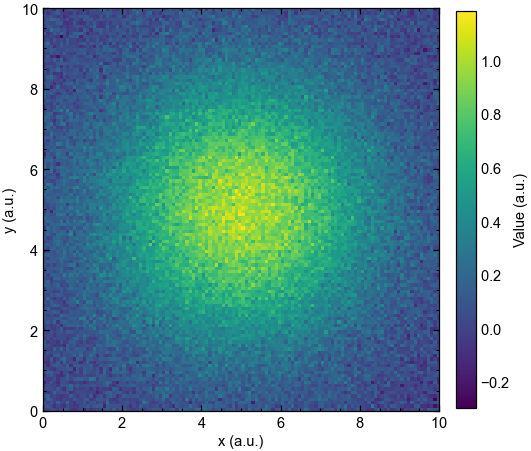

In [2]:
preview("elsevier")
grid = np.linspace(-3, 3, 120)
field = np.exp(-((grid[:, None] ** 2 + grid[None, :] ** 2) / 4)) + 0.08 * rng.normal(size=(120, 120))

fig, ax = jf.subplots("elsevier", width="single", ratio=0.85)
mesh = ax.imshow(field, extent=(0, 10, 0, 10), origin="lower", aspect="auto")
fig.colorbar(mesh, ax=ax, label="Value (a.u.)", fraction=0.05, pad=0.02)
ax.set_xlabel("x (a.u.)")
ax.set_ylabel("y (a.u.)")

## The colorbar trap

`fig.colorbar` reserves `fraction=0.15` of the parent axes' width by default. On a wide panel that
leaves a large gap between the panel and a bar sized by its own aspect ratio. `fraction=0.05,
pad=0.02` is a reasonable starting point.

Text(0, 0.5, 'y (a.u.)')

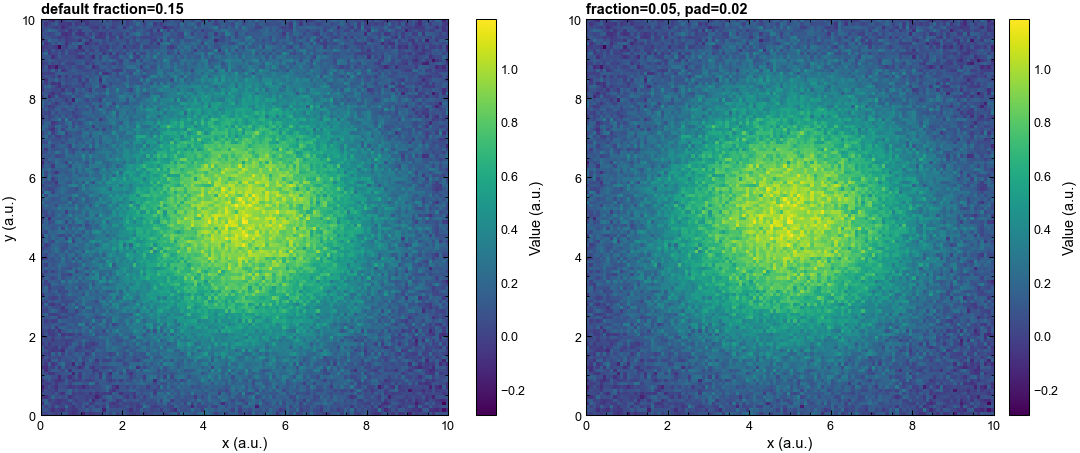

In [3]:
preview("nature")
fig, axs = jf.subplots("nature", 1, 2, width="double", ratio=0.42)

m0 = axs[0].imshow(field, extent=(0, 10, 0, 10), origin="lower", aspect="auto")
fig.colorbar(m0, ax=axs[0], label="Value (a.u.)")
axs[0].set_title("default fraction=0.15")

m1 = axs[1].imshow(field, extent=(0, 10, 0, 10), origin="lower", aspect="auto")
fig.colorbar(m1, ax=axs[1], label="Value (a.u.)", fraction=0.05, pad=0.02)
axs[1].set_title("fraction=0.05, pad=0.02")

for ax in axs:
    ax.set_xlabel("x (a.u.)")
axs[0].set_ylabel("y (a.u.)")

## Choosing a colormap

Use a perceptually uniform map — `viridis` (the theme default), `magma`, `cividis`. They stay
monotonic when printed in greyscale, which rainbow maps do not: `jet` invents banding that is not in
the data and collapses to ambiguous grey.

## Better still: the Crameri maps

`viridis` is a large improvement on `jet`, but the scientific colour maps of Crameri (*The misuse of
colour in science communication*, Nature Communications, 2020) go further: they are perceptually
uniform *and* readable to colour-vision-deficient readers *and* they hold up in greyscale. They come
from the optional `cmcrameri` package:

```bash
pip install cmcrameri     # or: pip install "journalfig[examples]"
```

`batlow` is the sequential default, `vik` and `roma` are diverging, `lajolla` reads as depth. The cell
below falls back to matplotlib's built-ins if the package is not installed, so this notebook runs
either way.

using cmcrameri: batlow and vik


Text(0, 0.5, 'y (a.u.)')

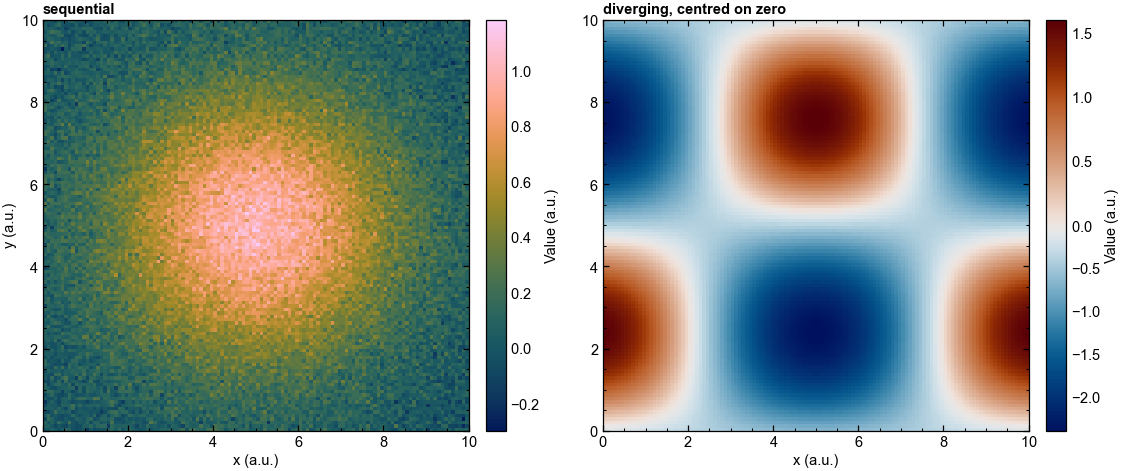

In [4]:
from matplotlib.colors import TwoSlopeNorm

signed_field = np.sin(grid[:, None]) * np.cos(grid[None, :]) * 2 - 0.4

try:
    from cmcrameri import cm as cmc

    SEQUENTIAL, DIVERGING = cmc.batlow, cmc.vik
    print("using cmcrameri:", SEQUENTIAL.name, "and", DIVERGING.name)
except ImportError:
    SEQUENTIAL, DIVERGING = "viridis", "RdBu_r"
    print("cmcrameri not installed; falling back to", SEQUENTIAL, "and", DIVERGING)

preview("elsevier")
fig, axs = jf.subplots("elsevier", 1, 2, width="double", ratio=0.42)

m0 = axs[0].imshow(field, extent=(0, 10, 0, 10), origin="lower", aspect="auto", cmap=SEQUENTIAL)
fig.colorbar(m0, ax=axs[0], label="Value (a.u.)", fraction=0.05, pad=0.02)
axs[0].set_title("sequential")

m1 = axs[1].imshow(signed_field, extent=(0, 10, 0, 10), origin="lower", aspect="auto",
                   cmap=DIVERGING, norm=TwoSlopeNorm(vcenter=0.0))
fig.colorbar(m1, ax=axs[1], label="Value (a.u.)", fraction=0.05, pad=0.02)
axs[1].set_title("diverging, centred on zero")

for ax in axs:
    ax.set_xlabel("x (a.u.)")
axs[0].set_ylabel("y (a.u.)")

Text(0.5, 0, 'Value (a.u.)')

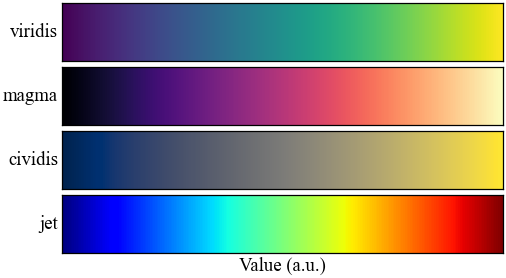

In [5]:
preview("aps")
ramp = np.tile(np.linspace(0, 1, 256), (24, 1))

fig, axs = jf.subplots("aps", 4, 1, width="single", ratio=0.55)
for ax, cmap in zip(axs, ["viridis", "magma", "cividis", "jet"]):
    ax.imshow(ramp, cmap=cmap, aspect="auto")
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_ylabel(cmap, rotation=0, ha="right", va="center")
axs[-1].set_xlabel("Value (a.u.)")

## Diverging data

When zero is meaningful, a diverging map centred on it says so. `TwoSlopeNorm` pins the centre even
when the data is not symmetric.

Text(0, 0.5, 'y (a.u.)')

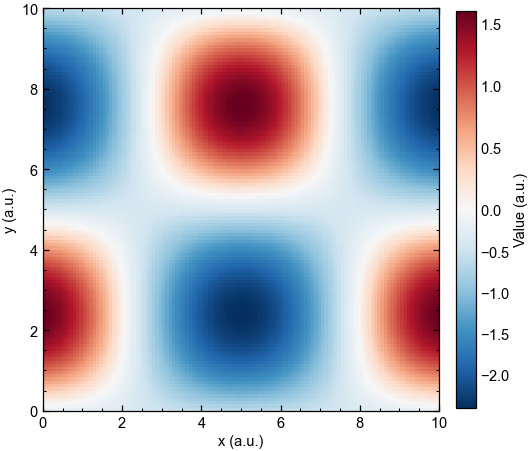

In [6]:
preview("elsevier")

fig, ax = jf.subplots("elsevier", width="single", ratio=0.85)
mesh = ax.imshow(signed_field, extent=(0, 10, 0, 10), origin="lower", aspect="auto",
                 cmap="RdBu_r", norm=TwoSlopeNorm(vcenter=0.0))
fig.colorbar(mesh, ax=ax, label="Value (a.u.)", fraction=0.05, pad=0.02)
ax.set_xlabel("x (a.u.)")
ax.set_ylabel("y (a.u.)")

## Discrete levels

`BoundaryNorm` turns a continuous map into bands, which is easier to read off a printed page than a
smooth gradient when the reader needs values rather than shape.

Text(0, 0.5, 'y (a.u.)')

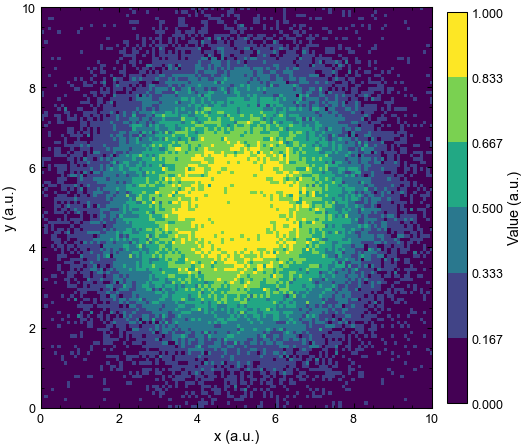

In [7]:
from matplotlib.colors import BoundaryNorm

preview("nature")
levels = np.linspace(0, 1, 7)

fig, ax = jf.subplots("nature", width="single", ratio=0.85)
mesh = ax.imshow(field.clip(0, 1), extent=(0, 10, 0, 10), origin="lower", aspect="auto",
                 cmap="viridis", norm=BoundaryNorm(levels, ncolors=256))
fig.colorbar(mesh, ax=ax, label="Value (a.u.)", fraction=0.05, pad=0.02, ticks=levels)
ax.set_xlabel("x (a.u.)")
ax.set_ylabel("y (a.u.)")

## `pcolormesh` for non-uniform grids

`imshow` assumes evenly spaced cells. When the coordinates are irregular, `pcolormesh` places each
cell where it belongs.

Text(0, 0.5, 'y (a.u.)')

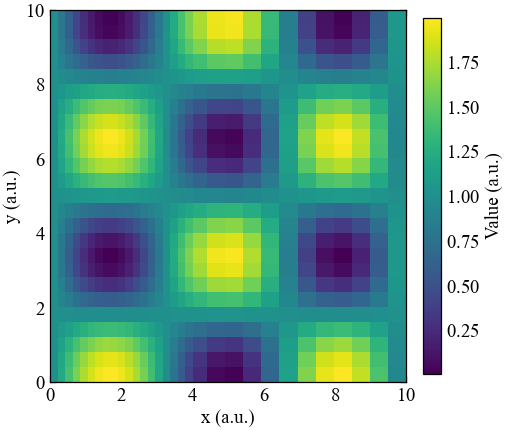

In [8]:
preview("aps")
x_edges = np.concatenate([np.linspace(0, 4, 20), np.linspace(4.4, 10, 12)])
y_edges = np.linspace(0, 10, 26)
values = np.sin(x_edges[None, :-1]) * np.cos(y_edges[:-1, None]) + 1

fig, ax = jf.subplots("aps", width="single", ratio=0.85)
mesh = ax.pcolormesh(x_edges, y_edges, values, cmap="viridis")
fig.colorbar(mesh, ax=ax, label="Value (a.u.)", fraction=0.05, pad=0.02)
ax.set_xlabel("x (a.u.)")
ax.set_ylabel("y (a.u.)")

## Rasterize the heavy artist, not the figure

`imshow` embeds a bitmap, so it is never the problem. `pcolormesh` is: it draws one vector quad per
cell, which on a large grid means a PDF holding hundreds of thousands of paths — slow to open, large
enough for a submission system to refuse, and prone to hairline seams where antialiasing leaves gaps
between neighbouring quads.

`rasterized=True` converts **that one artist** to a bitmap at `savefig.dpi` while the axes, ticks and
labels stay live vector text. It is the fix, not a compromise.

In [9]:
import tempfile
from pathlib import Path

outdir = Path(tempfile.mkdtemp())
dense_x = np.linspace(0, 10, 400)
dense_y = np.linspace(0, 10, 400)
dense_z = np.sin(dense_x[None, :]) * np.cos(dense_y[:, None])

jf.use("nature")
for label, raster in [("vector quads", False), ("rasterized=True", True)]:
    fig, ax = jf.subplots("nature", width="single", ratio=0.85)
    ax.pcolormesh(dense_x, dense_y, dense_z, rasterized=raster)
    ax.set_xlabel("x (a.u.)")
    ax.set_ylabel("y (a.u.)")
    (path,) = jf.save(fig, outdir / label.split()[0], formats=["pdf"], validate=False)
    print(f"{label:16s} {path.stat().st_size / 1024:8.1f} kB")
    plt.close(fig)

Nature Portfolio: 89.0 x 75.6 mm -> vector.pdf


Nature Portfolio: 89.0 x 75.6 mm -> rasterized=True.pdf


vector quads       3651.9 kB
rasterized=True     108.4 kB


`jf.check()` reports this too. It is the one rule in the checker that no publisher document states —
it is the package's own judgement about what makes a file impractical — so it fires only well past
what an ordinary plot produces.

In [10]:
jf.use("nature")
fig, ax = jf.subplots("nature", width="single", ratio=0.85)
ax.pcolormesh(dense_x, dense_y, dense_z)          # 160,000 cells, not rasterized
ax.set_xlabel("x (a.u.)")
ax.set_ylabel("y (a.u.)")

print("VECTOR_ELEMENT_LIMIT =", f"{jf.VECTOR_ELEMENT_LIMIT:,}")
for violation in jf.check(fig, warn=False):
    print(violation)
plt.close(fig)

VECTOR_ELEMENT_LIMIT = 50,000
[vector] a QuadMesh holds 160,000 elements and is not rasterized; the vector file will be very large — pass rasterized=True to that call so only it becomes a bitmap, leaving axes and text as text


A heatmap is raster data either way, so also ask whether the array is denser than the printed figure
can resolve: at 89 mm and 600 dpi that is about 2100 pixels across. Downsampling beyond that discards
nothing a reader could have seen.